# **Lab 9 - Morphological Operations**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'Pics/Erosion.jpg'

# **Erosion Operations**

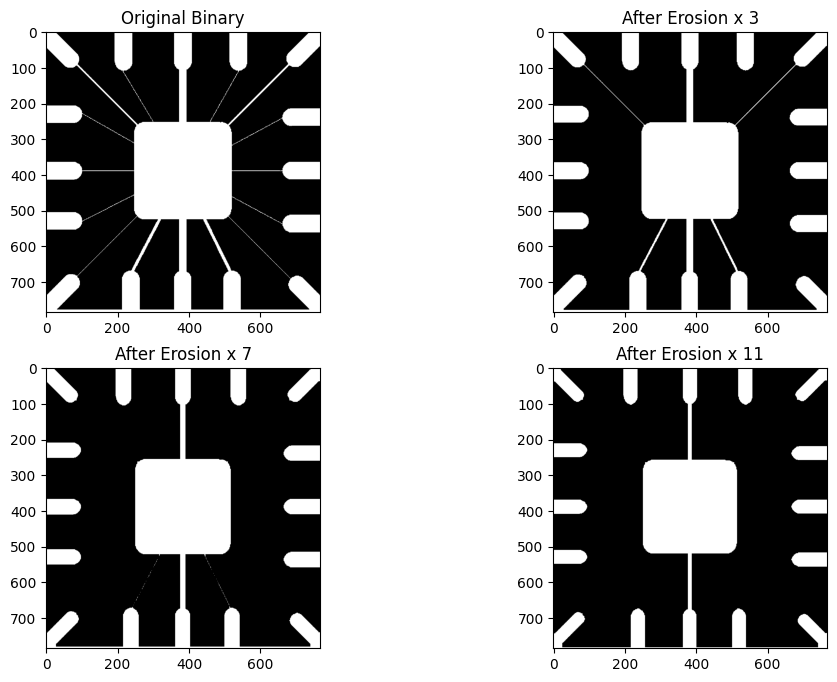

In [2]:

# 1. Load image and convert to grayscale
img = cv2.imread(imgFile, 0)

# 2. Binarize the image (Otsu's method works well for varying light)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Define a 3x3 kernel (all ones), you can define kernel of size 5x5, 7x7, ... any odd x odd
# Larger kernels lead to more aggressive erosion

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)

# 4. Apply erosion
# 'iterations' determines how many times the operation is repeated,
# ===> You can change iterations values to apply same process multiple times.

eroded_img3 = cv2.erode(binary, kernel3, iterations=1)
eroded_img7 = cv2.erode(binary, kernel7, iterations=1)
eroded_img11 = cv2.erode(binary, kernel11, iterations=1)

# 5. Display comparison
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original Binary')
plt.subplot(2, 2, 2), plt.imshow(eroded_img3, 'gray'), plt.title('After Erosion x 3')
plt.subplot(2, 2, 3), plt.imshow(eroded_img7, 'gray'), plt.title('After Erosion x 7')
plt.subplot(2, 2, 4), plt.imshow(eroded_img11, 'gray'), plt.title('After Erosion x 11')


plt.show()


# **Dilation Operations**

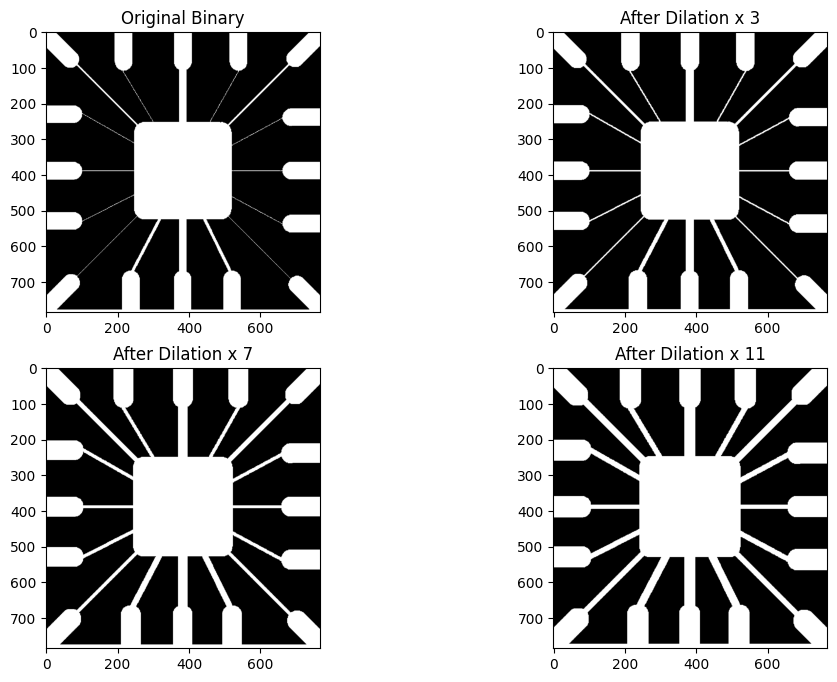

In [3]:

# 1. Load image and convert to grayscale
img = cv2.imread(imgFile, 0)

# 2. Binarize the image (Otsu's method works well for varying light)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Define a 3x3 kernel (all ones), you can define kernel of size 5x5, 7x7, ... any odd x odd
# Larger kernels lead to more aggressive erosion

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)

# 4. Apply erosion
# 'iterations' determines how many times the operation is repeated,
# ===> You can change iterations values to apply same process multiple times.

eroded_img3 = cv2.dilate(binary, kernel3, iterations=1)
eroded_img7 = cv2.dilate(binary, kernel7, iterations=1)
eroded_img11 = cv2.dilate(binary, kernel11, iterations=1)

# 5. Display comparison
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original Binary')
plt.subplot(2, 2, 2), plt.imshow(eroded_img3, 'gray'), plt.title('After Dilation x 3')
plt.subplot(2, 2, 3), plt.imshow(eroded_img7, 'gray'), plt.title('After Dilation x 7')
plt.subplot(2, 2, 4), plt.imshow(eroded_img11, 'gray'), plt.title('After Dilation x 11')


plt.show()


# **Morphological Open Operations**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'Pics/Open_Closing.jpg'

# 1. Load image and binarize
img = cv2.imread(imgFile, 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Define kernel (a 5x5 square is a good starting point)
kernel = np.ones((5, 5), np.uint8)

# 3. Apply Opening
# This is equivalent to: dilate(erode(binary))
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 4. Display comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original (with Noise)')
plt.subplot(1, 2, 2), plt.imshow(opening, 'gray'), plt.title('After Opening')
plt.show()

# **Closing Morphological Operation**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'Pics/Opening2.jpg'

# 1. Load image and binarize
img = cv2.imread(imgFile, 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Define kernel (a 45x45 square is a good starting point)
kernel = np.ones((45, 45), np.uint8)

# 3. Apply Closing
# Effectively: cv2.erode(cv2.dilate(binary, kernel), kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# 4. Display comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original (with Noise)')
plt.subplot(1, 2, 2), plt.imshow(closing, 'gray'), plt.title('After Closing')
plt.show()

# **Boundaries Extractions**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'Pics/BoundaryExtraction.jpg'

# 1. Load and binarize the image (foreground must be white)
img = cv2.imread(imgFile, 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Define a kernel (the size controls boundary thickness)
kernel = np.ones((3, 3), np.uint8)

# 3. Method A: Morphological Gradient (Built-in standard)
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

# 4. Method B: Internal Boundary (Original - Eroded)
eroded = cv2.erode(binary, kernel)
internal = cv2.subtract(binary, eroded)

# 5. Method C: External Boundary (Dilated - Original)
dilated = cv2.dilate(binary, kernel)
external = cv2.subtract(dilated, binary)

# Visualization
titles = ['Original', 'Gradient', 'Internal', 'External']
images = [binary, gradient, internal, external]

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()